# P3 이론: 경사하강법

**주요 내용**

P3 실습과 같은 **1인당 GDP와 삶의 만족도** 예제를 이용하여,
선형 회귀 모델이 좋은 절편과 기울기를 어떻게 찾아가는지 이해한다.

이론의 순서도 실습과 같은 흐름을 따른다.

> **직선과 오차 → MSE → 파라미터 업데이트 → 경사하강법 → 학습률 → 배치·스텝·에포크**

복잡한 수식 계산보다 **모델이 손실을 줄이기 위해 파라미터를 조금씩 바꾸어 가는 과정**을 이해하는 데 집중한다.

## 1단계: 좋은 직선은 무엇인가

### P0의 삶의 만족도 데이터를 다시 사용한다

P0에서는 국가별 **1인당 GDP**를 이용하여 **삶의 만족도**를 예측했다.

P3 실습에서도 같은 데이터를 사용한다.
1인당 GDP가 23,500달러에서 62,500달러 사이인 **31개 국가**를 선택한다.

이번에는 경사하강법의 움직임을 쉽게 보기 위해 GDP를 **1만 달러 단위**로 바꾸어 사용한다.

예를 들어

$$ 40{,}000\text{달러} \rightarrow 4.0 $$

으로 표현한다.

단위만 바뀌었을 뿐 데이터의 관계는 그대로다.

아래 그래프는 P3 실습에서 실제로 사용한 31개 국가의 데이터다.

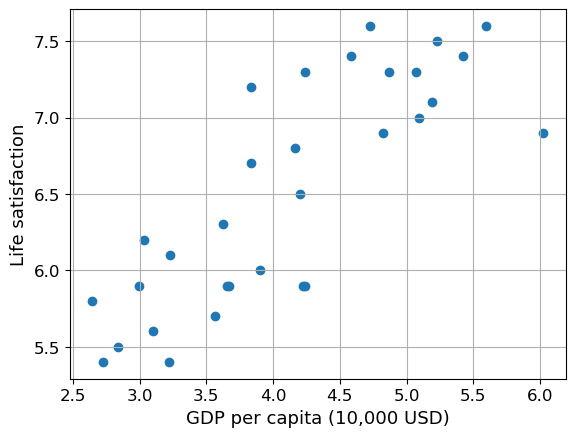

### 직선은 두 개의 파라미터로 정해진다

하나의 특성을 사용하는 선형 회귀 모델은 다음 직선을 사용한다.

$$ \hat y = \theta_0 + \theta_1 x $$

- $\theta_0$: 절편
- $\theta_1$: 기울기
- $x$: 1인당 GDP
- $\hat y$: 예측한 삶의 만족도

$\theta_0$와 $\theta_1$처럼 **훈련 과정에서 데이터로부터 결정되는 값**을
**모델 파라미터**(model parameter)라고 한다.

P3 실습에서는 P0에서 보았던 세 직선을 다시 비교한다.

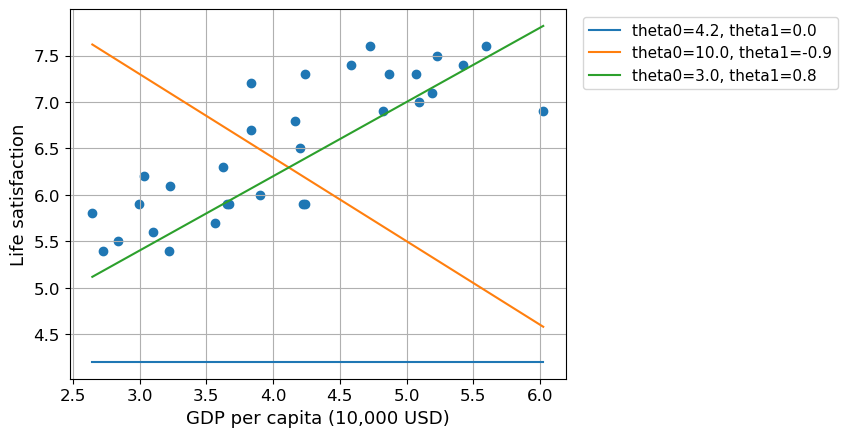

세 직선은 같은 데이터를 보지만 서로 다른 예측을 만든다.

- $\theta_0=4.2$, $\theta_1=0.0$
- $\theta_0=10.0$, $\theta_1=-0.9$
- $\theta_0=3.0$, $\theta_1=0.8$

그러면 어떤 직선이 더 좋은지 숫자로 비교할 기준이 필요하다.

### 평균 제곱 오차 MSE

회귀에서는 **평균 제곱 오차**(MSE)를 사용할 수 있다.

$$ \mathrm{MSE} = \frac{1}{m} \sum_{i=1}^{m} (\hat y^{(i)}-y^{(i)})^2 $$

공식을 다음 순서로 읽으면 된다.

> **예측값과 실제값의 차이를 구한다 → 제곱한다 → 전체 데이터의 평균을 구한다**

따라서 예측값과 실제값의 차이가 클수록 MSE가 커지고,
잘 맞을수록 MSE가 작아진다.

P3 실습에서 세 직선의 MSE는 다음과 같다.

| $\theta_0$ | $\theta_1$ | MSE |
|---:|---:|---:|
| 4.2 | 0.0 | 5.887097 |
| 10.0 | -0.9 | 2.196645 |
| 3.0 | 0.8 | 0.243992 |

세 후보 중에서는

$$ \theta_0=3.0,\qquad \theta_1=0.8 $$

인 직선의 MSE가 가장 작다.

하지만 이보다 더 좋은 절편과 기울기가 있을 수도 있다.

따라서 모델 훈련의 목표는

> **MSE를 더 작게 만드는 파라미터를 찾는 것**

이라고 볼 수 있다.

### 1단계 확인

다음을 자신의 말로 설명할 수 있는지 확인한다.

- 선형 회귀에서 $\theta_0$와 $\theta_1$은 무엇인가?
- 직선이 달라지면 무엇이 달라지는가?
- MSE가 작다는 것은 무엇을 의미하는가?
- 세 후보 직선 중 MSE가 가장 작은 직선은 어느 것인가?
- 세 후보만 비교하는 것으로 충분하지 않은 이유는 무엇인가?

## 2단계: 경사하강법은 어떻게 좋은 직선을 찾는가

### 한 번에 정답을 맞히는 것이 아니라 조금씩 수정한다

경사하강법은 처음부터 최적의 $\theta_0$, $\theta_1$을 알고 시작하지 않는다.

먼저 어떤 값에서 시작한 다음 다음 과정을 반복한다.

> **현재 파라미터 → 예측 → MSE 확인 → MSE가 줄어드는 방향 확인 → 파라미터 조금 수정**

이 한 번의 수정을 **스텝**(step)이라고 생각할 수 있다.

파라미터를 수정하는 핵심 형태는 다음과 같다.

$$ \text{새 파라미터} = \text{현재 파라미터} - \text{학습률} \times \text{기울기} $$

여기서 **기울기**(gradient)는 현재 위치에서 파라미터를 어느 방향으로 바꾸면
MSE가 증가하는지를 알려준다.

따라서 MSE를 줄이려면 **gradient의 반대 방향**으로 움직인다.

### 직선의 기울기와 gradient는 다르다

여기서 '기울기'라는 말이 두 가지 의미로 사용되므로 구분해야 한다.

- $\theta_1$: 예측 직선 $\hat y=\theta_0+\theta_1x$의 **기울기**
- `gradient_1`: $\theta_1$을 바꾸었을 때 **MSE가 변하는 방향과 크기**

즉 $\theta_1$과 `gradient_1`은 같은 값이 아니다.

경사하강법에서 gradient는 **손실 함수인 MSE의 기울기**를 뜻한다.

### `gradient_0`, `gradient_1`은 왜 이렇게 계산할까

P3 실습에서는 다음 식을 사용한다.

$$ \text{gradient}_0 = 2\,\mathrm{mean}(\mathrm{error}) $$

$$ \text{gradient}_1 = 2\,\mathrm{mean}(\mathrm{error}\times x) $$

여기서

$$ \mathrm{error} = \hat y-y = \theta_0+\theta_1x-y $$

이다.

이 식이 나오는 이유를 아주 간단히 살펴보자.

MSE는

$$ \mathrm{MSE} = \frac{1}{m} \sum_{i=1}^{m} (\theta_0+\theta_1x_i-y_i)^2 $$

이다.

한 데이터의 오차를

$$ e_i=\theta_0+\theta_1x_i-y_i $$

라고 쓰면 제곱 오차는 $e_i^2$이다.

제곱한 값 $e_i^2$의 변화율에는 $2e_i$가 나타난다.
그리고

- $\theta_0$가 조금 변하면 예측값은 그만큼 그대로 변하므로 $1$이 곱해지고,
- $\theta_1$이 조금 변하면 예측값은 $x_i$에 비례하여 변하므로 $x_i$가 곱해진다.

그래서 전체 데이터의 평균을 취하면

$$ \frac{\partial \mathrm{MSE}}{\partial \theta_0} = \frac{2}{m}\sum_{i=1}^{m}e_i = 2\,\mathrm{mean}(\mathrm{error}) $$

$$ \frac{\partial \mathrm{MSE}}{\partial \theta_1} = \frac{2}{m}\sum_{i=1}^{m}e_i x_i = 2\,\mathrm{mean}(\mathrm{error}\times x) $$

가 된다.

수식을 암기하기보다 다음 의미를 기억하면 된다.

> `gradient_0`: 절편을 어느 방향으로 얼마나 바꿀 것인가  
> `gradient_1`: 직선의 기울기를 어느 방향으로 얼마나 바꿀 것인가

### 경사하강법을 직접 실행한다

P3 실습에서는 학습 과정을 쉽게 관찰하기 위해

$$ \theta_0=\theta_1=0 $$

에서 시작한다.

그리고 **31개 국가 전체**를 이용하여 MSE와 gradient를 계산한 다음
두 파라미터를 한 번씩 수정한다.

학습률은 먼저 `0.01`을 사용하고, 100 에포크 동안 학습한다.

실습에서 처음 몇 에포크의 결과는 다음과 같다.

| Epoch | $\theta_0$ | $\theta_1$ | MSE |
|---:|---:|---:|---:|
| 0 | 0.000000 | 0.000000 | 42.982581 |
| 1 | 0.130323 | 0.546907 | 17.286374 |
| 2 | 0.213032 | 0.888928 | 7.220559 |
| 5 | 0.322784 | 1.319566 | 1.126084 |
| 20 | 0.400992 | 1.449401 | 0.721997 |
| 100 | 0.634213 | 1.395338 | 0.650356 |

처음에는 MSE가 매우 크지만 파라미터를 반복해서 수정하면서 빠르게 작아진다.

### 직선이 어떻게 움직이는지 본다

P3 실습에서는 다음 에포크의 직선을 함께 그렸다.

`0, 1, 2, 5, 10, 20, 50, 100`

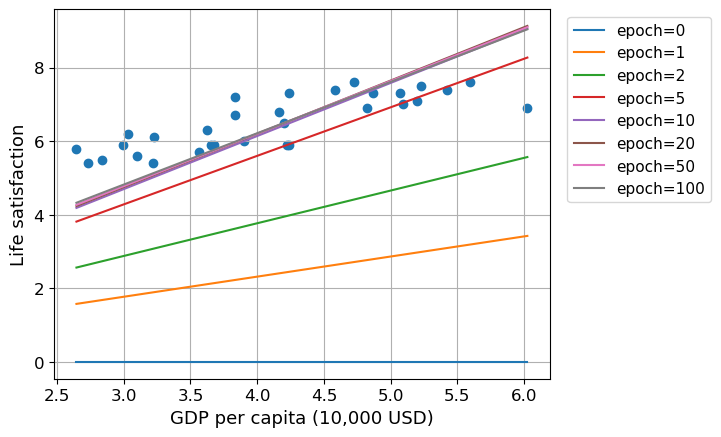

처음의 직선은 데이터와 거의 맞지 않는다.
하지만 파라미터를 반복해서 수정하면서 직선이 데이터의 전체적인 방향에 가까워진다.

이것이 `fit()` 내부에서 일어나는 **모델 훈련의 핵심 아이디어**다.

### MSE도 함께 확인한다

좋은 방향으로 학습되고 있다면
에포크가 진행될수록 MSE가 감소해야 한다.

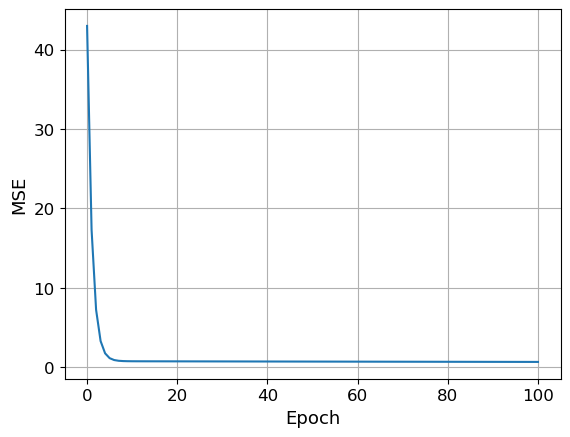

P3 실습에서는 처음 몇 번의 업데이트에서 MSE가 빠르게 감소하고,
이후에는 감소 폭이 점점 작아지는 모습을 확인할 수 있다.

파라미터가 변하고 있다는 사실만 보는 것이 아니라
**손실이 실제로 줄어드는지도 함께 확인해야 한다.**

### `LinearRegression`이 찾은 결과와 비교한다

P0에서는 `LinearRegression.fit()`을 이용하여 절편과 기울기를 자동으로 학습했다.

P3 실습에서 같은 데이터를 사용한 비교 결과는 다음과 같다.

| | 경사하강법, 100 epoch | `LinearRegression` |
|---|---:|---:|
| $\theta_0$ | 0.634213 | 3.839382 |
| $\theta_1$ | 1.395338 | 0.650545 |
| MSE | 0.650356 | 0.175290 |

100 에포크의 경사하강법은 처음보다 훨씬 작은 MSE에 도달했지만,
아직 `LinearRegression`의 결과와는 차이가 있다.

핵심은 두 방법이 같은 계산을 한다는 뜻이 아니다.

> **`fit()`은 데이터에 잘 맞는 파라미터를 찾는 과정이고, 경사하강법은 그 파라미터를 반복적인 수정으로 찾아가는 방법이다.**

### 학습률이 중요한 이유

**학습률**(learning rate)은 한 스텝에서 파라미터를 얼마나 크게 움직일지를 정한다.

P3 실습에서는 같은 데이터, 같은 모델, 같은 초기값에서
학습률만 다음과 같이 바꾸어 비교한다.

- `0.001`
- `0.01`
- `0.05`

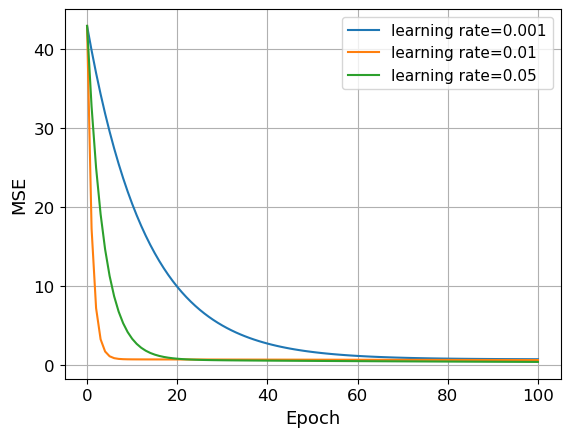

그래프에서 학습률이 작으면 MSE가 천천히 감소하고,
더 큰 학습률에서는 더 빠르게 감소할 수 있음을 볼 수 있다.

하지만 학습률을 계속 크게 한다고 항상 좋은 것은 아니다.

P3 실습에서는 학습률 `0.054`를 사용했을 때
MSE가 수렴하지 않고 폭발적으로 증가하는 모습을 확인한다.

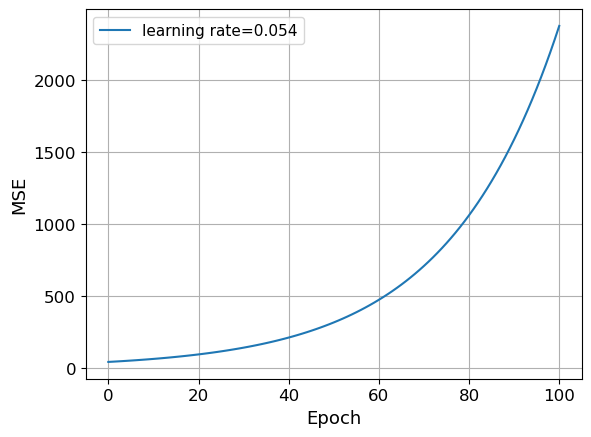

이를 **발산**(divergence)이라고 한다.

- 학습률이 너무 작으면 파라미터가 조금씩만 움직여 학습이 느리다.
- 적절한 학습률이면 MSE가 빠르게 감소한다.
- 학습률이 너무 크면 MSE가 불안정하게 움직이거나 발산할 수 있다.

여기서 `0.054`라는 숫자 자체를 일반적인 기준으로 외우면 안 된다.
좋은 학습률은 **데이터와 모델, 데이터의 스케일**에 따라 달라질 수 있다.

### GDP를 1만 달러 단위로 바꾼 이유와 연결한다

이제 1단계에서 GDP의 단위를 바꾼 이유를 경사하강법과 연결할 수 있다.

`gradient_1`은

$$ \text{gradient}_1 = 2\,\mathrm{mean}(\mathrm{error}\times x) $$

이므로 입력값 $x$의 크기가 gradient의 크기에 직접 영향을 준다.

GDP를 40,000처럼 큰 숫자로 그대로 사용하면
같은 오차에서도 `error × x`가 매우 커질 수 있다.

반면 1만 달러 단위로 바꾸면

$$ 40{,}000\rightarrow4.0 $$

이 되어 같은 학습률에서 지나치게 큰 업데이트가 일어나는 문제를 줄이는 데 도움이 된다.

이 원리는 P3 프로젝트에서 여러 특성의 스케일을 맞추는 이유와도 연결된다.

### 배치 → 스텝 → 에포크 → 학습률

P3 실습의 예제로 네 용어를 연결한다.

**배치**(batch)  
한 번의 파라미터 업데이트에 사용하는 데이터 묶음이다.  
이번 실습에서는 31개 국가 **전체**를 한 번에 사용한다.

**스텝**(step)  
한 배치로 예측하고 MSE와 gradient를 계산한 뒤
$\theta_0$, $\theta_1$을 한 번 업데이트하는 과정이다.

**에포크**(epoch)  
훈련 데이터 전체를 한 번 사용한 과정이다.  
이번 예제에서는 한 배치가 전체 31개 국가이므로 **한 스텝이 곧 한 에포크**다.

**학습률**(learning rate)  
각 스텝에서 파라미터를 얼마나 크게 움직일지를 정한다.

이번 실습처럼 **훈련 데이터 전체를 한 배치로 사용하는 경사하강법**을
**배치 경사하강법**(batch gradient descent)이라고 한다.

### 2단계 확인

다음을 자신의 말로 설명할 수 있는지 확인한다.

- 모델의 파라미터는 무엇인가?
- MSE가 작다는 것은 무엇을 의미하는가?
- $\theta_1$과 `gradient_1`은 어떻게 다른가?
- `gradient_0 = 2 × mean(error)`가 되는 이유를 간단히 설명할 수 있는가?
- `gradient_1 = 2 × mean(error × x)`에서 왜 $x$가 곱해지는가?
- 경사하강법은 왜 gradient의 반대 방향으로 움직이는가?
- 학습률이 하는 역할은 무엇인가?
- 학습률이 너무 크면 왜 발산할 수 있는가?
- 이번 실습에서 한 스텝과 한 에포크가 같은 이유는 무엇인가?

## 이론 정리

이번 이론에서 기억할 핵심은 다음과 같다.

- 선형 회귀의 훈련은 데이터에 잘 맞는 **절편과 가중치**를 찾는 과정이다.
- 모델의 예측 오차는 MSE와 같은 손실 함수로 측정할 수 있다.
- 경사하강법은 손실을 줄이는 방향으로 파라미터를 조금씩 수정한다.
- gradient는 파라미터를 바꿀 때 MSE가 어떻게 변하는지를 나타낸다.
- $\theta_1$은 예측 직선의 기울기이고, `gradient_1`은 MSE의 변화 방향과 크기를 나타내는 값이다.
- 학습률은 한 번에 얼마나 크게 수정할지를 결정한다.
- 학습률이 너무 크면 MSE가 감소하지 않고 발산할 수 있다.
- 입력 특성의 크기는 gradient의 크기에 영향을 줄 수 있다.
- 이번 예제에서는 훈련셋 전체를 한 배치로 사용했으며, 이를 **배치 경사하강법**이라고 한다.
- 한 배치가 전체 훈련셋이므로 이번 예제에서는 **한 스텝이 곧 한 에포크**다.

> **모델 훈련 = 예측 → 오차 확인 → 파라미터 수정 → 반복**